# Tutorial 2: Stop detection in trajectories

This notebook shows how to process device-level trajectory data, in different formats, to detect stops using ```nomad```. Stop detection is an important step in
pre-processing trajectory data and in making sense of trajectories by grouping together pings that reflect stationary behavior. The output of stop-detection algorithms is commonly a "stop table", indicating when a stop started, its duration, and a pair of coordinates that approximates the location of the group of pings (typically the centroid). Alternatively, ```nomad``` allows users to retrieve a cluster label for each ping (useful for plotting, for example)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

In [8]:
import filters
import daphmeIO as loader
import constants as constants
import stop_detection_modified as SD

ModuleNotFoundError: No module named 'geopandas'

In [5]:
import pandas as pd
from scipy.spatial.distance import pdist, cdist
import numpy as np
import math
import datetime as dt
from datetime import timedelta
import matplotlib.pyplot as plt
import itertools
from collections import defaultdict
import sys
import os
import pdb

## Load data sample

For these examples we load some test data from ```nomad``` which has the following trajectory columns (notice that ```traj_cols``` maps the data's column names to default names used by ```nomad```)

In [6]:
traj_cols = {'user_id':'user_id',
             'latitude':'dev_lat',
             'longitude':'dev_lon',
             'datetime':'local_datetime'}

In [7]:
path = '../data/sample4/'
data = loader.from_file(path, traj_cols=traj_cols, format='csv')

NameError: name 'loader' is not defined

This synthetic data has records for 100 users for a 1 week period, with spherical coordinates (lat, lon) and datetime format for the time component of each ping. 

In [160]:
data.head()

,user_id,dev_lat,dev_lon,local_datetime
0,wizardly_joliot,38.321711,-36.667334,2024-01-01 14:29:00
1,wizardly_joliot,38.321676,-36.667365,2024-01-01 14:35:00
2,wonderful_swirles,38.321017,-36.667869,2024-01-01 15:06:00
3,youthful_galileo,38.321625,-36.666612,2024-01-01 08:47:00
4,youthful_galileo,38.321681,-36.666841,2024-01-01 09:59:00


## Stop detection algorithms

The stop detection algorithms in ```nomad``` are applied to each user's trajectories separately. Thus, we demonstrate first by sampling a single user's data.

In [161]:
user_sample = data.loc[data.user_id == "angry_spence"]

In [238]:
TIME_THRESH = 100
DIST_THRESH = 40

In [9]:
def _find_neighbors_hdbscan(data, time_thresh, dist_thresh, long_lat, datetime, traj_cols, alpha=0.5):
    """
    - Computes pairwise distances between points based on space & time.
    - If two points are connected, the matrix stores the weighted distance.
    - Returns a weighted adjacency matrix, where edges represent spatiotemporal proximity.
    """
    if long_lat:
        coords = np.radians(data[[traj_cols['latitude'], traj_cols['longitude']]].values)
    else:
        coords = data[[traj_cols['x'], traj_cols['y']]].values

    if datetime:
        times = data[traj_cols['datetime']].astype('datetime64[s]').astype(int).values
    else:
        # if timestamps, we change the values to seconds
        first_timestamp = data[traj_cols['timestamp']].iloc[0]
        timestamp_length = len(str(first_timestamp))

        if timestamp_length > 10:
            if timestamp_length == 13:
                times = data[traj_cols['timestamp']].values.view('int64') // 10 ** 3
            elif timestamp_length == 19:
                times = data[traj_cols['timestamp']].values.view('int64') // 10 ** 9   
        else:
            times = data[traj_cols['timestamp']].values

    n = len(data)

    adjacency_matrix = {t: {} for t in times}
    
    # Pairwise time differences (convert seconds to minutes)
    time_diffs = np.abs(times[:, np.newaxis] - times) / 60.0

    # Compute spatial distances
    if long_lat:
        distances = np.array([[_haversine_distance(coords[i], coords[j]) for j in range(n)] for i in range(n)])
    else:
        distances = np.sqrt((coords[:, 0][:, np.newaxis] - coords[:, 0])**2 + 
                            (coords[:, 1][:, np.newaxis] - coords[:, 1])**2)

    # Normalize distances
    max_dist = np.max(distances) if np.max(distances) > 0 else 1
    max_time = np.max(time_diffs) if np.max(time_diffs) > 0 else 1

    distances /= max_dist
    time_diffs /= max_time

    # compute weighted combination
    weighted_distances = alpha * distances + (1 - alpha) * time_diffs

    # apply a threshold to keep only valid neighbors
    threshold = alpha * dist_thresh / max_dist + (1 - alpha) * time_thresh / max_time
    
    for i, t1 in enumerate(times):
        for j, t2 in enumerate(times):
            if weighted_distances[i, j] < threshold and i != j:
                adjacency_matrix[t1][t2] = weighted_distances[i, j]
    
    return adjacency_matrix

def _construct_mst(adjacency_matrix):
    """
    - Uses Prim’s algorithm to construct a Minimum Spanning Tree (MST).
    - Works with a dictionary-based adjacency matrix indexed by timestamps.
    - The edges retain spatiotemporal weights computed earlier.
    - Ensures that every point remains part of the same structure.

    Parameters
    ----------
    adjacency_matrix : dict of dict
        A dictionary where keys are timestamps and values are dictionaries of {neighbor_timestamp: weight}.

    Returns
    -------
    list of tuples
        A list of MST edges in the format: (weight, timestamp1, timestamp2).
    """
    timestamps = list(adjacency_matrix.keys())
    mst_edges = []
    visited = {t: False for t in timestamps}
    pq = []

    def find_next_start():
        for t in timestamps:
            if not visited[t] and adjacency_matrix[t]:
                return t
        return None

    start_node = find_next_start()

    while start_node is not None:
        visited[start_node] = True
        for neighbor, weight in adjacency_matrix[start_node].items():
            heappush(pq, (weight, start_node, neighbor))

        while pq:
            weight, u, v = heappop(pq)

            # only skip edges where both nodes are visited
            if visited[u] and visited[v]:
                continue

            mst_edges.append((weight, u, v))

            # visit the unvisited node
            next_node = v if not visited[v] else u
            visited[next_node] = True

            for neighbor, edge_weight in adjacency_matrix[next_node].items():
                if not visited[neighbor]:
                    heappush(pq, (edge_weight, next_node, neighbor))

        start_node = find_next_start()

    return mst_edges

def _extract_hierarchy(mst_edges, all_timestamps):
    """
    - Sorts MST edges by decreasing weight (weakest connections are removed first).
    - Start with individual points as their own clusters.
    - Iteratively merges clusters, creating a tree-like structure (dendrogram).
    - Assigns `-1` to completely isolated timestamps (i.e., those missing from MST).
    
    Parameters
    ----------
    mst_edges : list of tuples
        A list of edges in the format: (weight, timestamp1, timestamp2).
    all_timestamps : set
        The full set of timestamps that should be included in the clustering process.
    
    Returns
    -------
    np.ndarray
        A hierarchical linkage matrix representing the clustering process.
    dict
        A dictionary mapping timestamps to their cluster labels (including `-1` for noise).
    """

    # sort edges by descending weight (removing weak connections first)
    sorted_edges = sorted(mst_edges, reverse=True, key=lambda x: x[0])

    # initialize all timestamps as their own cluster
    clusters = {t: t for t in all_timestamps}
    cluster_tree = []
    cluster_count = max(all_timestamps) + 1

    for weight, u, v in sorted_edges:
        root_u, root_v = clusters[u], clusters[v]

        # only merge if they belong to different clusters
        if root_u != root_v:
            new_cluster = cluster_count
            cluster_count += 1

            # update all points in both clusters to the new cluster ID
            for key in clusters.keys():
                if clusters[key] in (root_u, root_v):
                    clusters[key] = new_cluster

            # compute cluster size
            cluster_size = sum(1 for x in clusters.values() if x == new_cluster)

            # append to the cluster tree
            cluster_tree.append((root_u, root_v, weight, cluster_size))

    # identify timestamps that were never merged (completely isolated)
    timestamps_in_mst = set()
    for _, u, v in mst_edges:
        timestamps_in_mst.update([u, v])

    isolated_timestamps = all_timestamps - timestamps_in_mst

    for t in isolated_timestamps:
        clusters[t] = -1

    return np.array(cluster_tree), clusters

def _flat_cut(linkage_matrix, clusters, threshold, min_cluster_size=5):
    """
    Perform a flat cut of the hierarchical clustering at the specified threshold.
    
    Parameters
    ----------
    linkage_matrix : np.ndarray
        The hierarchical linkage matrix from extract_hierarchy.
    clusters : dict
        Dictionary mapping timestamps to their initial cluster IDs.
    threshold : float
        The weight threshold at which to cut the dendrogram.
    min_cluster_size : int, default=5
        Minimum number of points required to form a valid cluster.
        
    Returns
    -------
    dict
        A dictionary mapping timestamps to their final cluster labels after the cut.
        Noise points are labeled as -1.
    """
    result_clusters = clusters.copy()
    
    # If we have an empty linkage matrix, return the original clusters
    if len(linkage_matrix) == 0:
        return result_clusters
    
    # Process the edges of the linkage matrix in order (from low to high weight)
    for i in range(len(linkage_matrix)):
        left, right, weight, size = linkage_matrix[i]
        
        # Only process edges with weights below the threshold
        if weight <= threshold:
            # Update all points in the 'right' cluster to be in the 'left' cluster
            for ts in result_clusters:
                if result_clusters[ts] == right:
                    result_clusters[ts] = left
    
    # Count the sizes of each cluster
    cluster_sizes = {}
    for cluster_id in result_clusters.values():
        if cluster_id == -1:
            continue
        if cluster_id not in cluster_sizes:
            cluster_sizes[cluster_id] = 0
        cluster_sizes[cluster_id] += 1
    
    # Mark clusters smaller than min_cluster_size as noise (-1)
    for ts in result_clusters:
        cluster_id = result_clusters[ts]
        if cluster_id != -1 and cluster_sizes.get(cluster_id, 0) < min_cluster_size:
            result_clusters[ts] = -1
    
    # Relabel the clusters to be consecutive integers starting from 0
    valid_clusters = sorted({c for c in result_clusters.values() if c != -1})
    mapping = {old_id: new_id for new_id, old_id in enumerate(valid_clusters)}
    mapping[-1] = -1  # Keep noise points as -1
    
    for ts in result_clusters:
        result_clusters[ts] = mapping[result_clusters[ts]]
    
    return result_clusters

def _find_optimal_threshold(linkage_matrix, clusters, min_cluster_size=5):
    """
    Find the optimal threshold for flat cutting by evaluating multiple criteria.
    
    Parameters
    ----------
    linkage_matrix : np.ndarray
        The hierarchical linkage matrix.
    clusters : dict
        Dictionary mapping timestamps to their cluster IDs.
    min_cluster_size : int, default=5
        Minimum cluster size to consider valid.
        
    Returns
    -------
    float
        The optimal threshold value.
    """
    if len(linkage_matrix) == 0:
        return 0.0
    
    # Get unique threshold values from the linkage matrix
    thresholds = sorted(np.unique(linkage_matrix[:, 2]))
    
    results = []
    for threshold in thresholds:
        # Apply the flat cut at this threshold
        flat_clusters = flat_cut(linkage_matrix, clusters, threshold, min_cluster_size)
        
        # Count valid clusters (excluding noise)
        valid_cluster_ids = set(flat_clusters.values()) - {-1}
        num_clusters = len(valid_cluster_ids)
        
        # Count points assigned to valid clusters vs. noise
        total_points = len(flat_clusters)
        assigned_points = sum(1 for c in flat_clusters.values() if c != -1)
        noise_ratio = 1.0 - (assigned_points / total_points if total_points > 0 else 0)
        
        # # Skip if we have too many clusters and a max is specified
        # if max_clusters is not None and num_clusters > max_clusters:
        #     continue
        
        # Calculate cluster stability
        # A stable cluster has a large "gap" from the next threshold
        if threshold == thresholds[-1]:
            stability = 0  # Last threshold has no stability measure
        else:
            next_idx = thresholds.index(threshold) + 1
            stability = thresholds[next_idx] - threshold
        
        # Calculate a score combining multiple factors
        # Higher score = better threshold
        #  - More clusters
        #  - Lower noise ratio
        #  - Higher stability
        score = (
            (num_clusters * 0.4) +
            ((1 - noise_ratio) * 0.4) +
            (stability * 5.0 * 0.2)
        )
        
        results.append((threshold, num_clusters, noise_ratio, stability, score))
    
    # Sort by score (descending) and get the best threshold
    results.sort(key=lambda x: x[4], reverse=True)
    
    if not results:
        # Return a default if no valid threshold was found
        return thresholds[0] if thresholds else 0.0
    
    best_threshold = results[0][0]
    return best_threshold

def hierarchical_temporal_dbscan(traj, time_thresh, dist_thresh, min_cluster_size = 10, traj_cols=None, complete_output=False, **kwargs):
    data = traj.copy()
    
    # Check if user wants long and lat
    long_lat = 'latitude' in kwargs and 'longitude' in kwargs and kwargs['latitude'] in data.columns and kwargs['longitude'] in data.columns

    # Check if user wants datetime
    datetime = 'datetime' in kwargs and kwargs['datetime'] in data.columns

    # Set initial schema
    if not traj_cols:
        traj_cols = {}

    traj_cols = loader._update_schema(traj_cols, kwargs)
    traj_cols = loader._update_schema(constants.DEFAULT_SCHEMA, traj_cols)

    # Ensure required spatial and temporal columns exist
    loader._has_spatial_cols(data.columns, traj_cols)
    loader._has_time_cols(data.columns, traj_cols)

    # Determine if we are using lat/lon or cartesian (meters)
    if traj_cols['x'] in data.columns and traj_cols['y'] in data.columns:
        long_lat = False
    else:
        long_lat = True

    if traj_cols['timestamp'] in data.columns:
        datetime = False
    else:
        datetime = True

    # Timestamp handling
    if datetime:
        time_col_name = traj_cols['datetime']
        # times = data[traj_cols['datetime']].astype('datetime64[s]').astype(int).values
        data['mapped_time'] = data[traj_cols['datetime']].astype('datetime64[s]').astype(int)
    else:
        first_timestamp = data[traj_cols['timestamp']].iloc[0]
        timestamp_length = len(str(first_timestamp))

        if timestamp_length > 10:
            if timestamp_length == 13:
                warnings.warn(
                    f"The '{data[traj_cols['timestamp']]}' column appears to be in milliseconds. "
                    "This may lead to inconsistencies."
                )
                time_col_name = traj_cols['timestamp']
                data['mapped_time'] = data[traj_cols['timestamp']].values.view('int64') // 10**3
                # times = data[traj_cols['timestamp']].values.view('int64') // 10 ** 3
            elif timestamp_length == 19:
                warnings.warn(
                    f"The '{time_col_name}' column appears to be in nanoseconds. "
                    "This may lead to inconsistencies."
                )
                time_col_name = traj_cols['timestamp']
                data['mapped_time'] = data[traj_cols['timestamp']].values.view('int64') // 10**9
                # times = data[traj_cols['timestamp']].values.view('int64') // 10 ** 9
        else:
            time_col_name = traj_cols['timestamp']
            data['mapped_time'] = data[traj_cols['timestamp']].values.view('int64')
            # times = data[traj_cols['timestamp']].values

    # Build weighted adjacency matrix
    adjacency_matrix = _find_neighbors_hdbscan(data, time_thresh, dist_thresh, long_lat, datetime, traj_cols, alpha=0.5)

    # Construct MST
    mst_edges = _construct_mst(adjacency_matrix)

    # Extract hierarchical tree structure
    cluster_tree, clusters = _extract_hierarchy(mst_edges, set(data['mapped_time'].unique()))

    # Find the optimal threshold for flat cutting
    optimal_threshold = _find_optimal_threshold(cluster_tree, clusters, min_cluster_size)

    # Apply flat cut at optimal threshold
    final_clusters = _flat_cut(cluster_tree, clusters, optimal_threshold, min_cluster_size)

    # Assign cluster labels based on `mapped_time`
    data['cluster'] = data['mapped_time'].map(final_clusters).fillna(-1).astype(int)
    
    hdbscan_out = data[[time_col_name, 'cluster']]

    # Remove noise (-1 clusters)
    data = data[data['cluster'] != -1]

    # Compute stop metrics per cluster
    stop_table = data.groupby('cluster').apply(
        lambda group: _stop_metrics(group, long_lat, datetime, traj_cols, complete_output), include_groups=False)
    
    # Return stop metrics + timestamps with final cluster labels
    return stop_table, hdbscan_out

In [10]:
stop_hdbscan, labels_hdbscan = hierarchical_temporal_dbscan(traj=user_sample,
            time_thresh=TIME_THRESH,
            dist_thresh=DIST_THRESH,
            traj_cols=traj_cols,
            complete_output=True).head()

NameError: name 'user_sample' is not defined

In [75]:
mult_users = data.loc[data.user_id.isin(["angry_spence", "stoic_almeida", "relaxed_colden", "dazzling_bassi"])]

In [76]:
user_sample.head()

,user_id,dev_lat,dev_lon,local_datetime
991,angry_spence,38.320990,-36.666555,2024-01-01 10:21:00
992,angry_spence,38.320962,-36.666504,2024-01-01 10:27:00
993,angry_spence,38.320955,-36.666495,2024-01-01 10:29:00
994,angry_spence,38.320947,-36.666521,2024-01-01 10:39:00
995,angry_spence,38.320955,-36.666527,2024-01-01 10:42:00


For this user, the trajectory data has 1696 rows (pings) and covers a period of 15 days (start date: 2024-01-01, end date: 2024-01-15). We can visualize the trajectory for one day below: 

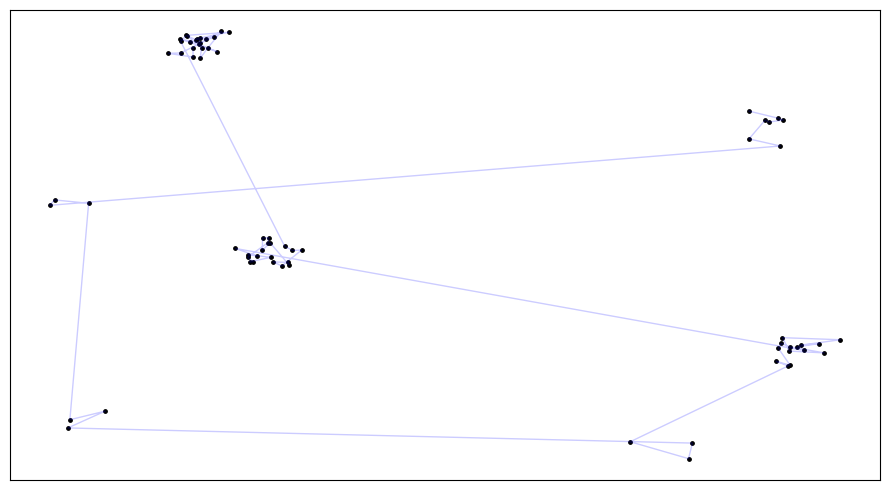

In [77]:
plot_data = user_sample[user_sample['local_datetime'].dt.date == pd.to_datetime('2024-01-01').date()]

fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(x=plot_data['dev_lon'], 
           y=plot_data['dev_lat'],
           s=6,
           color='black',
           alpha=1,
           zorder=2)

ax.plot(plot_data['dev_lon'],
        plot_data['dev_lat'],
        linewidth=1, color='blue', alpha=0.2)

ax.set_yticklabels([])
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

### Sequential stop detection (Lachesis)

The first stop detection algorithm implemented in ```nomad``` is a sequential algorithm described in "Project Lachesis: Parsing and Modeling Location Histories". This algorithm for extracting stays is dependent on two parameters: the roaming distance and the stay duration. Roaming distance represents the maximum distance an object can move away from a point location and still be considered to be staying at that location. Stay duration is the minimum amount of time an object must spend within the roaming distance of a location to qualify as a stay. The algorithm identifies contiguous sequences of raw location data points that stay within the roaming distance for at least the duration of the stay duration

This algorithm has the following parameters, which determine the size of the resulting stops:
* ```dur_min```: Minimum duration for a stay in minutes.
* ```dt_max```: Maximum time gap permitted between consecutive pings in a stay in minutes (dt_max should be greater than dur_min).
* ```delta_roam```: Maximum roaming distance for a stay in meters.

In [25]:
DUR_MIN = 60
DT_MAX = 120
DELTA_ROAM = 50

The Lachesis algorithm can output a complete table of attributes for identified stops, including the start time, end time, the medoid coordinates, duration, number of pings in the stop, and diameter.

In [11]:
%%time
SD.lachesis(traj=user_sample,
            dur_min=DUR_MIN,
            dt_max=DT_MAX,
            delta_roam=DELTA_ROAM,
            traj_cols=traj_cols,
            complete_output=True).head()

CPU times: user 285 ms, sys: 8.14 ms, total: 293 ms
Wall time: 303 ms


,start_time,end_time,dev_lon,dev_lat,diameter,n_pings,duration
0,2024-01-01 15:04:00,2024-01-01 16:16:00,-36.66647,38.320064,14.691535,14,72.0
1,2024-01-01 18:17:00,2024-01-01 20:58:00,-36.667398,38.320415,12.974932,19,161.0
2,2024-01-01 21:15:00,2024-01-02 01:10:00,-36.667525,38.321253,13.946715,32,235.0
3,2024-01-02 05:54:00,2024-01-02 08:01:00,-36.667489,38.321273,31.46013,17,127.0
4,2024-01-02 08:40:00,2024-01-02 11:59:00,-36.667721,38.320554,20.736412,39,199.0


In [28]:
%%time
mult_users.groupby(['user_id']).apply(lambda x: SD.lachesis(x.reset_index(), 
            dur_min=DUR_MIN,
            dt_max=DT_MAX,
            delta_roam=DELTA_ROAM,
            traj_cols=traj_cols,
            complete_output=True),include_groups=False)

CPU times: user 417 ms, sys: 26.9 ms, total: 444 ms
Wall time: 486 ms


start_time            end_time    dev_lon    dev_lat  \
user_id                                                                         
angry_spence  0 2024-01-01 15:04:00 2024-01-01 16:16:00  -36.66647  38.320064   
              1 2024-01-01 18:17:00 2024-01-01 20:58:00 -36.667398  38.320415   
              2 2024-01-01 21:15:00 2024-01-02 01:10:00 -36.667525  38.321253   
              3 2024-01-02 05:54:00 2024-01-02 08:01:00 -36.667489  38.321273   
              4 2024-01-02 08:40:00 2024-01-02 11:59:00 -36.667721  38.320554   
...                             ...                 ...        ...        ...   
stoic_almeida 0 2024-01-02 03:01:00 2024-01-02 05:33:00 -36.666804  38.320567   
              1 2024-01-08 20:49:00 2024-01-08 22:47:00 -36.666777  38.320628   
              2 2024-01-11 17:25:00 2024-01-11 18:58:00 -36.666655  38.321721   
              3 2024-01-12 09:55:00 2024-01-12 11:36:00 -36.666573  38.320041   
              4 2024-01-15 03:45:00 2024-01-15 06:19:00 -36.666782  38.320621   

                  diameter n_pings  duration  
user_id                                       
angry_spence  0  14.691535      14      72.0  
              1  12.974932      19     161.0  
              2  13.946715      32     235.0  
              3   31.46013      17     127.0  
              4  20.736412      39     199.0  
...                    ...     ...       ...  
stoic_almeida 0  12.015757       5     152.0  
              1    7.60821       4     118.0  
              2  40.073559       3      93.0  
              3  18.543835       3     101.0  
              4   11.12533       5     154.0  

[87 rows x 7 columns]

An additional argument, ```complete_output```, can be passed to only output the stop start time, duration, and medoid coordinates.

In [12]:
%%time
SD.lachesis(traj=user_sample,
            dur_min=DUR_MIN,
            dt_max=DT_MAX,
            delta_roam=DELTA_ROAM,
            traj_cols=traj_cols,
            complete_output=False).head()

CPU times: user 301 ms, sys: 8.92 ms, total: 310 ms
Wall time: 328 ms


,start_time,duration,dev_lon,dev_lat
0,2024-01-01 15:04:00,72.0,-36.66647,38.320064
1,2024-01-01 18:17:00,161.0,-36.667398,38.320415
2,2024-01-01 21:15:00,235.0,-36.667525,38.321253
3,2024-01-02 05:54:00,127.0,-36.667489,38.321273
4,2024-01-02 08:40:00,199.0,-36.667721,38.320554


We can also get the final cluster label for each of the pings, including those who were identified as noise.

In [87]:
%%time
cluster_lachesis = SD._lachesis_labels(traj=user_sample,
                    dur_min=DUR_MIN,
                    dt_max=DT_MAX,
                    delta_roam=DELTA_ROAM,
                    traj_cols=traj_cols)
cluster_lachesis.head(30)

CPU times: user 308 ms, sys: 11.2 ms, total: 320 ms
Wall time: 331 ms


,cluster
2024-01-01 10:21:00,-1
2024-01-01 10:27:00,-1
2024-01-01 10:29:00,-1
2024-01-01 10:39:00,-1
2024-01-01 10:42:00,-1
2024-01-01 11:00:00,-1
2024-01-01 11:13:00,-1
2024-01-01 11:22:00,-1
2024-01-01 11:25:00,-1
2024-01-01 11:28:00,-1


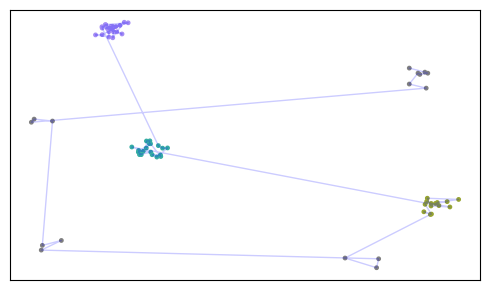

In [42]:
plot_data_lachesis = user_sample.merge(cluster_lachesis, left_on='local_datetime', right_index=True, how='left')

plot_data_lachesis = plot_data_lachesis[plot_data_lachesis['local_datetime'].dt.date == pd.to_datetime('2024-01-01').date()]

import matplotlib.pyplot as plt
import seaborn as sns
palette = sns.color_palette("husl", n_colors=len(plot_data_lachesis['cluster'].unique()))
cluster_colors = {c: palette[i] for i, c in enumerate(plot_data_lachesis['cluster'].unique())}
cluster_colors[-1] = 'gray'

fig, ax = plt.subplots(figsize=(5, 3))

ax.scatter(x=plot_data_lachesis['dev_lon'], 
           y=plot_data_lachesis['dev_lat'],
           s=6,
           c=plot_data_lachesis['cluster'].map(cluster_colors),
           alpha=1,
           zorder=2)

ax.plot(plot_data_lachesis['dev_lon'],
        plot_data_lachesis['dev_lat'],
        linewidth=1, color='blue', alpha=0.2)

ax.set_yticklabels([])
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

The data could also come with different formats for spatial and temporal variables, the algorithm can handle those situations as well.

In [14]:
%%time
# x, y, timestamp (unix time)
traj_cols_x_y_timestamp = {'user_id':'user_id',
                          'x':'x',
                          'y':'y',
                          'timestamp':'unix_time'}

user_sample_x_y_timestamp = user_sample.copy()
user_sample_x_y_timestamp = filters.to_projection(user_sample_x_y_timestamp, longitude='dev_lon', latitude='dev_lat')
user_sample_x_y_timestamp['unix_time'] = user_sample_x_y_timestamp['local_datetime'].astype('int64') // 10**9

# Lachesis with x, y, and timestamp (unix time)
SD.lachesis(user_sample_x_y_timestamp, DUR_MIN, DT_MAX, DELTA_ROAM, traj_cols=traj_cols_x_y_timestamp, complete_output=False).head()

CPU times: user 74.3 ms, sys: 3.31 ms, total: 77.6 ms
Wall time: 89.5 ms


,start_time,duration,x,y
0,1.704121e+09,72.0,-4.081693e+06,4.624739e+06
1,1.704133e+09,161.0,-4.081796e+06,4.624789e+06
2,1.704144e+09,235.0,-4.081810e+06,4.624908e+06
3,1.704175e+09,127.0,-4.081806e+06,4.624911e+06
4,1.704185e+09,199.0,-4.081832e+06,4.624809e+06


### Density based stop detection (Temporal DBSCAN)

The second stop detection algorithm implemented in ```nomad``` is a density-based algorithm with time-constraints, Temporal DBSCAN. 

This algorithm for clustering user pings combines temporal and spatial dimensions, relying on three key parameters: the time threshold, the distance threshold, and the minimum number of points. The time threshold defines the maximum time difference (in minutes) between two consecutive pings for them to be considered neighbors within the same cluster. The distance threshold specifies the maximum spatial distance (in meters) between two pings for them to be considered neighbors. The minimum points parameter sets the minimum number of points required for a dense region to form a cluster. If a region contains fewer than minimum number of points required, it is treated as noise. The algorithm identifies clusters by grouping contiguous pings that meet both the temporal and spatial criteria, while also ensuring that each cluster has enough density to be considered valid.

This algorithm has the following parameters, which determine the size of the resulting stops:
* ```time_thresh```: Time threshold in minutes for identifying neighbors.
* ```dist_thresh```: Distance threshold in meters for identifying neighbors.
* ```min_pts```: Minimum number of points required to form a dense region (core point).

In [15]:
TIME_THRESH = 100
DIST_THRESH = 40
MIN_PTS = 10

Similarly to Lachesis, the Temporal DBSCAN algorithm can output a complete table of attributes for identified stops, including the start time, end time, the medoid coordinates, duration, number of pings in the stop, and diameter.

In [16]:
%%time
SD.temporal_dbscan(user_sample,
                   TIME_THRESH,
                   DIST_THRESH,
                   MIN_PTS,
                   traj_cols=traj_cols,
                   complete_output=True).head()

CPU times: user 13.4 s, sys: 606 ms, total: 14 s
Wall time: 14.3 s


,start_time,end_time,dev_lon,dev_lat,diameter,n_pings,duration
cluster,,,,,,,
0,2024-01-04 16:02:00,2024-01-04 16:45:00,-0.639973,0.668841,11.374422,14,43.0
1,2024-01-14 19:45:00,2024-01-15 07:39:00,-0.639968,0.668818,22.775558,87,714.0
2,2024-01-14 14:10:00,2024-01-14 15:39:00,-0.639963,0.668810,14.062991,13,89.0
3,2024-01-14 01:45:00,2024-01-14 07:52:00,-0.639956,0.668827,13.814779,57,367.0
4,2024-01-13 13:53:00,2024-01-13 16:45:00,-0.639952,0.668824,61.588256,18,172.0


The additional argument ```complete_output``` can also be passed to only output the stop start time, duration, and medoid coordinates.

In [17]:
%%time
SD.temporal_dbscan(user_sample,
                   TIME_THRESH,
                   DIST_THRESH,
                   MIN_PTS,
                   traj_cols=traj_cols,
                   complete_output=False).head()

CPU times: user 13.3 s, sys: 523 ms, total: 13.8 s
Wall time: 14.1 s


,start_time,duration,dev_lon,dev_lat
cluster,,,,
0,2024-01-04 16:02:00,43.0,-0.639973,0.668841
1,2024-01-14 19:45:00,714.0,-0.639968,0.668818
2,2024-01-14 14:10:00,89.0,-0.639963,0.668810
3,2024-01-14 01:45:00,367.0,-0.639956,0.668827
4,2024-01-13 13:53:00,172.0,-0.639952,0.668824


We can also get the final cluster and core labels for each of the pings.

In [118]:
%%time
cluster_dbscan = SD._temporal_dbscan_labels(user_sample,
                           TIME_THRESH,
                           DIST_THRESH,
                           MIN_PTS,
                           traj_cols=traj_cols)

cluster_dbscan.head(10)

CPU times: user 13.1 s, sys: 693 ms, total: 13.8 s
Wall time: 13.9 s


,cluster,core
2024-01-01 10:21:00,-1,-1
2024-01-01 10:27:00,-1,-1
2024-01-01 10:29:00,-1,-1
2024-01-01 10:39:00,-1,-1
2024-01-01 10:42:00,-1,-1
2024-01-01 11:00:00,-1,-1
2024-01-01 11:13:00,-1,-1
2024-01-01 11:22:00,-1,-1
2024-01-01 11:25:00,-1,-1
2024-01-01 11:28:00,-1,-1


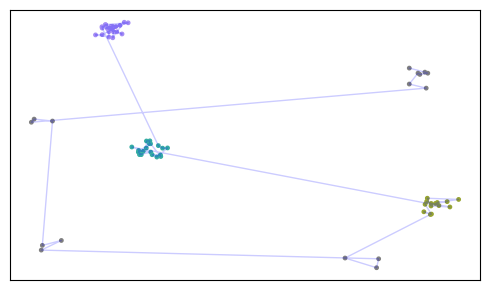

In [120]:
plot_data_dbscan = user_sample.merge(cluster_lachesis, left_on='local_datetime', right_index=True, how='left')

plot_data_dbscan = plot_data_dbscan[plot_data_dbscan['local_datetime'].dt.date == pd.to_datetime('2024-01-01').date()]

import matplotlib.pyplot as plt
import seaborn as sns
palette = sns.color_palette("husl", n_colors=len(plot_data_dbscan['cluster'].unique()))
cluster_colors = {c: palette[i] for i, c in enumerate(plot_data_dbscan['cluster'].unique())}
cluster_colors[-1] = 'gray'

fig, ax = plt.subplots(figsize=(5, 3))

ax.scatter(x=plot_data_dbscan['dev_lon'], 
           y=plot_data_dbscan['dev_lat'],
           s=6,
           c=plot_data_dbscan['cluster'].map(cluster_colors),
           alpha=1,
           zorder=2)

ax.plot(plot_data_dbscan['dev_lon'],
        plot_data_dbscan['dev_lat'],
        linewidth=1, color='blue', alpha=0.2)

ax.set_yticklabels([])
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

The Temporal DBSCAN algorithm also handles data that comes with different formats for spatial and temporal variables.

In [19]:
%%time
SD.temporal_dbscan(user_sample_x_y_timestamp,
                   TIME_THRESH,
                   DIST_THRESH,
                   MIN_PTS,
                   traj_cols=traj_cols_x_y_timestamp,
                   complete_output=False).head()

CPU times: user 3.49 s, sys: 497 ms, total: 3.98 s
Wall time: 4.11 s


,start_time,duration,x,y
cluster,,,,
0,1.704384e+09,43.0,-4.081836e+06,4.624984e+06
1,1.705262e+09,714.0,-4.081802e+06,4.624791e+06
2,1.705241e+09,89.0,-4.081771e+06,4.624728e+06
3,1.705197e+09,367.0,-4.081725e+06,4.624865e+06
4,1.705158e+09,99.0,-4.081703e+06,4.624845e+06


# Home Detection

In [47]:
import pygeohash as pgh

In [60]:
example_stop_table = SD.lachesis(traj=user_sample, dur_min=DUR_MIN, dt_max=DT_MAX, delta_roam=DELTA_ROAM, traj_cols=traj_cols, complete_output=True)

In [61]:
example_stop_table

,start_time,end_time,dev_lon,dev_lat,diameter,n_pings,duration
0,2024-01-01 15:04:00,2024-01-01 16:16:00,-36.66647,38.320064,14.691535,14,72.0
1,2024-01-01 18:17:00,2024-01-01 20:58:00,-36.667398,38.320415,12.974932,19,161.0
2,2024-01-01 21:15:00,2024-01-02 01:10:00,-36.667525,38.321253,13.946715,32,235.0
3,2024-01-02 05:54:00,2024-01-02 08:01:00,-36.667489,38.321273,31.46013,17,127.0
4,2024-01-02 08:40:00,2024-01-02 11:59:00,-36.667721,38.320554,20.736412,39,199.0
5,2024-01-03 09:26:00,2024-01-03 10:27:00,-36.667738,38.320675,49.433588,12,61.0
6,2024-01-03 10:39:00,2024-01-03 11:56:00,-36.667853,38.321051,24.082471,8,77.0
7,2024-01-03 13:01:00,2024-01-03 17:37:00,-36.667299,38.320045,47.749101,44,276.0
8,2024-01-03 18:06:00,2024-01-04 01:16:00,-36.66676,38.32098,33.545006,48,430.0
9,2024-01-04 01:19:00,2024-01-04 02:32:00,-36.667507,38.321394,16.765689,15,73.0


In [107]:
import pandas as pd
import pygeohash as pgh

def home_detection(stop_table, night_start, night_end, geohash_precision, min_pings, local_tz='America/New_York'):
    """
    min number of nights
    min duration of stop
    min number of weeks
    output: home for each day per each user (compressed) -> 

    
    Detects home locations based on stops occurring at night.

    Parameters
    ----------
    stop_table : pd.DataFrame
        DataFrame containing stop information with 'start_time' and 'end_time'.
    night_start : int
        Start hour for night period (e.g., 19 for 7:00 PM).
    night_end : int
        End hour for night period (e.g., 7 for 7:00 AM).
    geohash_precision : int
        Precision level for geohashing locations.
    min_pings : int
        Minimum number of pings to consider for a home.
    local_tz : str
        Timezone to convert timestamps (e.g., 'America/New_York').

    Returns
    -------
    pd.DataFrame
        Filtered stops within the night period with geohash encoding.
    """
    home_table = stop_table.copy()

    # convert timestamps to local timezone
    home_table['start_time_tz'] = pd.to_datetime(home_table['start_time']).dt.tz_localize('UTC').dt.tz_convert(local_tz)
    home_table['end_time_tz'] = pd.to_datetime(home_table['end_time']).dt.tz_localize('UTC').dt.tz_convert(local_tz)

    # stops between night_start and 24:00
    df1 = home_table[(home_table['start_time_tz'].dt.hour.isin(range(night_start, 24))) & 
                     (home_table['end_time_tz'].dt.hour.isin(range(night_start, 24)))]

    # stops spanning night_start to night_end
    df2 = home_table[(home_table['start_time_tz'].dt.hour.isin(range(night_start, 24))) & 
                     (home_table['end_time_tz'].dt.hour < night_end)]

    # stops between 00:00 and night_end
    df3 = home_table[(home_table['start_time_tz'].dt.hour < night_end) & 
                     (home_table['end_time_tz'].dt.hour < night_end)]

    filtered_df = pd.concat([df1, df2, df3], ignore_index=True)
    # filtered_df = filtered_df[filtered_df['n_pings'] >= min_pings]

    filtered_df['pgh_encoding'] = filtered_df.apply(lambda x: pgh.encode(latitude=x['dev_lat'], longitude=x['dev_lon'], precision=geohash_precision), axis=1)

    return filtered_df.drop(columns=['start_time_tz', 'end_time_tz'])

In [145]:
homes = home_detection(example_stop_table, night_start = 22, night_end = 6, min_pings = 15, geohash_precision = 8)
homes

,start_time,end_time,dev_lon,dev_lat,diameter,n_pings,duration,pgh_encoding
0,2024-01-04 04:54:00,2024-01-04 07:57:00,-36.667502,38.321389,16.362749,31,183.0,envfj85w
1,2024-01-10 03:33:00,2024-01-10 06:23:00,-36.6674,38.320404,15.939312,27,170.0,envfj858
2,2024-01-02 05:54:00,2024-01-02 08:01:00,-36.667489,38.321273,31.46013,17,127.0,envfj85t
4,2024-01-05 08:05:00,2024-01-05 10:47:00,-36.667811,38.320681,32.54632,17,162.0,envfj856
6,2024-01-08 08:22:00,2024-01-08 10:03:00,-36.667845,38.320605,41.718132,16,101.0,envfj853
7,2024-01-12 06:24:00,2024-01-12 07:59:00,-36.667472,38.320984,10.926358,15,95.0,envfj85e
8,2024-01-12 08:02:00,2024-01-12 10:40:00,-36.666798,38.321656,42.543583,22,158.0,envfj8hp


In [146]:
cluster_lachesis

,cluster
2024-01-01 10:21:00,-1
2024-01-01 10:27:00,-1
2024-01-01 10:29:00,-1
2024-01-01 10:39:00,-1
2024-01-01 10:42:00,-1
...,...
2024-01-15 07:23:00,49
2024-01-15 07:29:00,49
2024-01-15 07:33:00,49
2024-01-15 07:39:00,49


In [147]:
user_sample

,user_id,dev_lat,dev_lon,local_datetime
991,angry_spence,38.320990,-36.666555,2024-01-01 10:21:00
992,angry_spence,38.320962,-36.666504,2024-01-01 10:27:00
993,angry_spence,38.320955,-36.666495,2024-01-01 10:29:00
994,angry_spence,38.320947,-36.666521,2024-01-01 10:39:00
995,angry_spence,38.320955,-36.666527,2024-01-01 10:42:00
...,...,...,...,...
25830,angry_spence,38.320399,-36.667438,2024-01-15 07:23:00
25831,angry_spence,38.320413,-36.667469,2024-01-15 07:29:00
25832,angry_spence,38.320384,-36.667455,2024-01-15 07:33:00
25833,angry_spence,38.320349,-36.667473,2024-01-15 07:39:00


In [148]:
output = user_sample.copy()
output['home'] = '-1'

# Iterate through detected stops and assign labels
for home_idx, home in homes.iterrows():
    stop_start = pd.to_datetime(home['start_time'])
    stop_end = pd.to_datetime(home['end_time'])
    output.loc[(output['local_datetime'] >= stop_start) & (output['local_datetime'] <= stop_end), 'home'] = home['pgh_encoding']

output

,user_id,dev_lat,dev_lon,local_datetime,home
991,angry_spence,38.320990,-36.666555,2024-01-01 10:21:00,-1
992,angry_spence,38.320962,-36.666504,2024-01-01 10:27:00,-1
993,angry_spence,38.320955,-36.666495,2024-01-01 10:29:00,-1
994,angry_spence,38.320947,-36.666521,2024-01-01 10:39:00,-1
995,angry_spence,38.320955,-36.666527,2024-01-01 10:42:00,-1
...,...,...,...,...,...
25830,angry_spence,38.320399,-36.667438,2024-01-15 07:23:00,-1
25831,angry_spence,38.320413,-36.667469,2024-01-15 07:29:00,-1
25832,angry_spence,38.320384,-36.667455,2024-01-15 07:33:00,-1
25833,angry_spence,38.320349,-36.667473,2024-01-15 07:39:00,-1


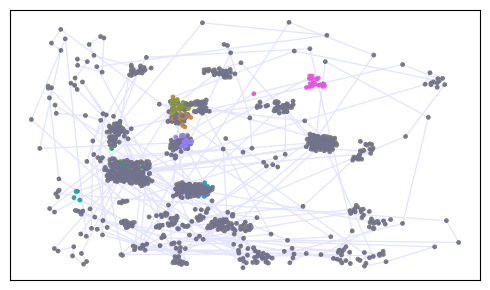

In [154]:
fig, ax = plt.subplots(figsize=(5, 3))

palette = sns.color_palette("husl", n_colors=len(output['home'].unique()))
cluster_colors = {c: palette[i] for i, c in enumerate(output['home'].unique())}
cluster_colors['-1'] = 'gray'

ax.scatter(x=output['dev_lon'], 
           y=output['dev_lat'],
           s=6,
           c=output['home'].map(cluster_colors),
           alpha=1,
           zorder=2)

ax.plot(output['dev_lon'],
        output['dev_lat'],
        linewidth=1,
        color='blue',
        alpha=0.1)

ax.set_yticklabels([])
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()